In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import kagglehub

from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split                    
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix,balanced_accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB 
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier, RandomForestClassifier

/home/orlandojunior/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.competition_download('playground-series-s6e7')

print("Path to competition files:", path)

Path to competition files: /home/orlandojunior/.cache/kagglehub/competitions/playground-series-s6e7


In [3]:
df_train = pd.read_csv(f'{path}/train.csv')
df_test = pd.read_csv(f'{path}/test.csv')
ids = df_test['id']

le = LabelEncoder()
le.fit(df_train['health_condition'])
df_train['health_condition'] = le.fit_transform(df_train['health_condition'])

df = pd.concat([df_train,df_test], axis=0, sort=False)
df = df.reset_index(drop=True)
df = df.drop(columns=['id'])
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 985841 entries, 0 to 985840
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   health_condition         690088 non-null  float64
 1   sleep_duration           877271 non-null  float64
 2   heart_rate               974651 non-null  float64
 3   bmi                      965987 non-null  float64
 4   calorie_expenditure      910336 non-null  float64
 5   step_count               965961 non-null  float64
 6   exercise_duration        975982 non-null  float64
 7   water_intake             923731 non-null  float64
 8   diet_type                975982 non-null  str    
 9   stress_level             867540 non-null  str    
 10  sleep_quality            902511 non-null  str    
 11  physical_activity_level  933525 non-null  str    
 12  smoking_alcohol          945010 non-null  str    
 13  gender                   955308 non-null  str    
dtypes: float64(8), 

In [4]:
def create_numerical_features(df):
    df_out = df.copy()
    
    # Constante minúscula para evitar o erro de Divisão por Zero (ZeroDivisionError)
    # ou a geração de valores infinitos (Inf) no Pandas.
    eps = 1e-5 
    df_out['steps_per_minute'] = df_out['step_count'] / (df_out['exercise_duration'] + eps)
    df_out['calories_per_minute'] = df_out['calorie_expenditure'] / (df_out['exercise_duration'] + eps)
    df_out['calories_per_step'] = df_out['calorie_expenditure'] / (df_out['step_count'] + eps)
    df_out['water_per_exercise_min'] = df_out['water_intake'] / (df_out['exercise_duration'] + eps)
    df_out['water_per_calorie'] = df_out['water_intake'] / (df_out['calorie_expenditure'] + eps)
    df_out['sleep_to_exercise_ratio'] = df_out['sleep_duration'] / (df_out['exercise_duration'] + eps)
    df_out['calories_per_bmi'] = df_out['calorie_expenditure'] / (df_out['bmi'] + eps)
    df_out['cardio_load'] = df_out['exercise_duration'] * df_out['heart_rate']

    return df_out

In [5]:
df.tail()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
985836,NaN,7.13,77.5,22.20,2221.0,13981.0,65.6,2.17,balanced,low,average,active,occasional,other
985837,NaN,6.25,69.5,20.93,2242.0,2370.0,23.6,1.98,balanced,NaN,average,moderate,yes,female
985838,NaN,NaN,77.0,23.62,2111.0,7647.0,25.1,2.18,veg,high,average,sedentary,no,other
985839,NaN,7.25,66.3,21.47,2009.0,4672.0,25.1,2.02,veg,high,poor,moderate,no,female
985840,NaN,4.61,85.1,23.79,2456.0,14195.0,50.5,2.30,non-veg,high,average,active,occasional,other


In [6]:
df.isna().sum()

health_condition           295753
sleep_duration             108570
heart_rate                  11190
bmi                         19854
calorie_expenditure         75505
step_count                  19880
exercise_duration            9859
water_intake                62110
diet_type                    9859
stress_level               118301
sleep_quality               83330
physical_activity_level     52316
smoking_alcohol             40831
gender                      30533
dtype: int64

In [7]:
df.describe()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.000000,877271.000000,974651.000000,965987.000000,910336.000000,965961.000000,975982.000000,923731.000000
mean,0.224973,6.992873,75.091421,22.984846,2225.913934,8619.156300,38.765033,2.189432
std,0.584513,1.215695,8.157156,2.480862,347.617428,3927.975501,14.732901,0.518575
min,0.000000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,0.000000,6.160000,69.400000,21.320000,2052.000000,5391.000000,29.200000,1.850000
50%,0.000000,6.990000,75.100000,22.990000,2240.000000,8856.000000,39.400000,2.180000
75%,0.000000,7.810000,80.700000,24.660000,2456.000000,12115.000000,49.400000,2.500000
max,2.000000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


## Tratar valores nulos

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 985841 entries, 0 to 985840
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   health_condition         690088 non-null  float64
 1   sleep_duration           877271 non-null  float64
 2   heart_rate               974651 non-null  float64
 3   bmi                      965987 non-null  float64
 4   calorie_expenditure      910336 non-null  float64
 5   step_count               965961 non-null  float64
 6   exercise_duration        975982 non-null  float64
 7   water_intake             923731 non-null  float64
 8   diet_type                975982 non-null  str    
 9   stress_level             867540 non-null  str    
 10  sleep_quality            902511 non-null  str    
 11  physical_activity_level  933525 non-null  str    
 12  smoking_alcohol          945010 non-null  str    
 13  gender                   955308 non-null  str    
dtypes: float64(8), 

In [9]:
df.isna().sum()

health_condition           295753
sleep_duration             108570
heart_rate                  11190
bmi                         19854
calorie_expenditure         75505
step_count                  19880
exercise_duration            9859
water_intake                62110
diet_type                    9859
stress_level               118301
sleep_quality               83330
physical_activity_level     52316
smoking_alcohol             40831
gender                      30533
dtype: int64

In [10]:
print(df.isna().sum()/len(df) * 100) 

health_condition           30.000071
sleep_duration             11.012932
heart_rate                  1.135071
bmi                         2.013915
calorie_expenditure         7.658943
step_count                  2.016552
exercise_duration           1.000060
water_intake                6.300205
diet_type                   1.000060
stress_level               12.000008
sleep_quality               8.452682
physical_activity_level     5.306738
smoking_alcohol             4.141743
gender                      3.097153
dtype: float64


In [11]:
df['step_count'].describe()

count    965961.000000
mean       8619.156300
std        3927.975501
min        1002.000000
25%        5391.000000
50%        8856.000000
75%       12115.000000
max       14999.000000
Name: step_count, dtype: float64

<Axes: xlabel='health_condition', ylabel='calorie_expenditure'>

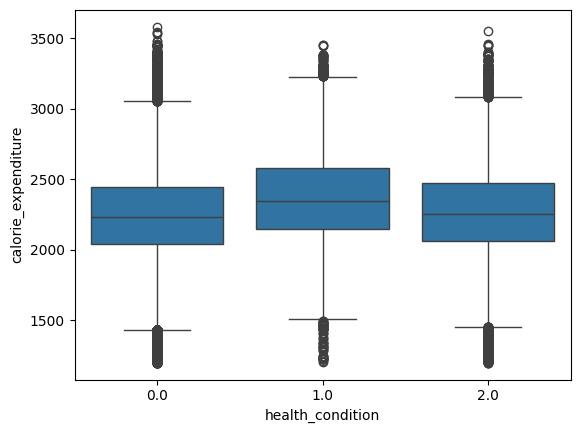

In [12]:
sns.boxplot(df,y='calorie_expenditure', x='health_condition')

In [13]:
numericas = df.select_dtypes(include=['number']).columns
categoricas = df.select_dtypes(include=['str']).columns

In [14]:
numericas_media = ['sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake']

In [15]:
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
imp_moda = SimpleImputer(missing_values=np.nan, strategy='most_frequent')


In [16]:
df[numericas_media] = imp_mean.fit_transform(df[numericas_media])
df[categoricas] = imp_moda.fit_transform(df[categoricas])

In [17]:
df = create_numerical_features(df)

In [18]:
df.isna().sum()

health_condition           295753
sleep_duration                  0
heart_rate                      0
bmi                             0
calorie_expenditure             0
step_count                      0
exercise_duration               0
water_intake                    0
diet_type                       0
stress_level                    0
sleep_quality                   0
physical_activity_level         0
smoking_alcohol                 0
gender                          0
steps_per_minute                0
calories_per_minute             0
calories_per_step               0
water_per_exercise_min          0
water_per_calorie               0
sleep_to_exercise_ratio         0
calories_per_bmi                0
cardio_load                     0
dtype: int64

In [19]:
for col in numericas:
    print(f'{col} - {df[col].nunique()}')

health_condition - 3
sleep_duration - 702
heart_rate - 542
bmi - 1613
calorie_expenditure - 2120
step_count - 13002
exercise_duration - 865
water_intake - 403


In [20]:
df['health_condition'].value_counts()

health_condition
0.0    592561
2.0     57724
1.0     39803
Name: count, dtype: int64

In [21]:
for col in categoricas:
    print(f'{col} - {df[col].nunique()}')

diet_type - 3
stress_level - 3
sleep_quality - 3
physical_activity_level - 3
smoking_alcohol - 3
gender - 3


In [22]:
preprocess = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numericas_media),
        ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False),categoricas)
    ],
    remainder="passthrough"
)

df_processed = preprocess.fit_transform(df)
nomes = preprocess.get_feature_names_out()

new_df = pd.DataFrame(df_processed, columns=nomes)
new_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 985841 entries, 0 to 985840
Data columns (total 34 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   num__sleep_duration                     985841 non-null  float64
 1   num__heart_rate                         985841 non-null  float64
 2   num__bmi                                985841 non-null  float64
 3   num__calorie_expenditure                985841 non-null  float64
 4   num__step_count                         985841 non-null  float64
 5   num__exercise_duration                  985841 non-null  float64
 6   num__water_intake                       985841 non-null  float64
 7   cat__diet_type_balanced                 985841 non-null  float64
 8   cat__diet_type_non-veg                  985841 non-null  float64
 9   cat__diet_type_veg                      985841 non-null  float64
 10  cat__stress_level_high                  985841 non-null

In [23]:
new_df.head()

,num__sleep_duration,num__heart_rate,num__bmi,num__calorie_expenditure,num__step_count,num__exercise_duration,num__water_intake,cat__diet_type_balanced,cat__diet_type_non-veg,cat__diet_type_veg,...,cat__gender_other,remainder__health_condition,remainder__steps_per_minute,remainder__calories_per_minute,remainder__calories_per_step,remainder__water_per_exercise_min,remainder__water_per_calorie,remainder__sleep_to_exercise_ratio,remainder__calories_per_bmi,remainder__cardio_load
0,-1.545930,-0.553763,1.089342,-0.155412,-1.875731,-1.293743,-0.656273,0.0,0.0,1.0,...,0.0,2.0,66.969663,109.797924,1.639517,0.093939,0.000856,0.263636,84.723272,1397.88
1,-1.275613,-0.467458,1.162639,-0.778092,0.327106,0.759597,-1.851555,0.0,1.0,0.0,...,1.0,0.0,198.216393,39.398790,0.198767,0.025250,0.000641,0.110822,76.083562,3557.87
2,-1.484891,0.038046,0.633270,1.383325,1.439456,-0.045367,-1.174229,0.0,0.0,1.0,...,0.0,2.0,373.123262,70.551163,0.189083,0.041995,0.000595,0.138845,109.535408,2872.74
3,-1.999366,0.259974,0.059108,1.209693,-0.371681,1.441770,-0.337532,0.0,0.0,1.0,...,0.0,2.0,119.766257,43.906504,0.366602,0.033723,0.000768,0.078464,113.705096,4624.28
4,0.206773,-0.208541,2.221378,1.000137,-0.523423,0.493550,0.120660,0.0,0.0,1.0,...,0.0,0.0,143.130404,55.652162,0.388821,0.048913,0.000879,0.157174,90.014033,3376.40


In [24]:
df_test.shape

(295753, 14)

In [25]:
df_training = new_df[:df_train.shape[0]]
df_testing = new_df[df_train.shape[0]:]

In [26]:
df_training.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 34 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   num__sleep_duration                     690088 non-null  float64
 1   num__heart_rate                         690088 non-null  float64
 2   num__bmi                                690088 non-null  float64
 3   num__calorie_expenditure                690088 non-null  float64
 4   num__step_count                         690088 non-null  float64
 5   num__exercise_duration                  690088 non-null  float64
 6   num__water_intake                       690088 non-null  float64
 7   cat__diet_type_balanced                 690088 non-null  float64
 8   cat__diet_type_non-veg                  690088 non-null  float64
 9   cat__diet_type_veg                      690088 non-null  float64
 10  cat__stress_level_high                  690088 non-null

In [27]:
df_testing = df_testing.drop(columns=['remainder__health_condition'])

In [28]:
X = df_training.drop(columns=['remainder__health_condition'])
y = df_training['remainder__health_condition']

In [29]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3,
                                                    shuffle=True, stratify=y)

X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5,
                                                    shuffle=True, stratify=y_temp)

X_train.shape, X_test.shape, X_val.shape

((483061, 33), (103513, 33), (103514, 33))

In [30]:
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

In [31]:
# param_dist = {
#     'n_estimators': stats.randint(800, 1200), 
#     'max_depth': stats.randint(3, 10),
#     'learning_rate': stats.uniform(0.01, 0.1),
#     'subsample': stats.uniform(0.5, 0.5),
#     'colsample_bytree': stats.uniform(0.5, 0.5),
#     'min_child_weight': stats.randint(1, 8),
#     'gamma': stats.uniform(0, 3)
# }

# # O XGBoost gerencia a GPU
# xgb_model = XGBClassifier(device='cuda')

# random_search = RandomizedSearchCV(
#     estimator=xgb_model,
#     param_distributions=param_dist, 
#     n_iter=10, 
#     cv=5, 
#     scoring='balanced_accuracy',
#     verbose=2,
#     n_jobs=1
# )

# random_search.fit(
#     X_train, 
#     y_train,
#     sample_weight=sample_weights
# )

In [32]:
# # params = random_search.best_params_
# params = {
#     'colsample_bytree': np.float64(0.6582899602669596),
#     'gamma': np.float64(2.8853554144681093),
#     'learning_rate': np.float64(0.022537428892352974),
#     'max_depth': 6,
#     'min_child_weight': 2,
#     'n_estimators': 1182,
#     'subsample': np.float64(0.920803446003165)
# }

In [33]:
# clf = XGBClassifier(**params,
#                         early_stopping_rounds = 5)
# clf.fit(X_train, y_train,                    
#             eval_set = [(X_val,y_val)],
#             sample_weight=sample_weights,
#             verbose = True)

In [38]:
base_models = [
    ('knn', KNeighborsClassifier()),
    ('r_forest', RandomForestClassifier()),
    ('gaussian', GaussianNB())
]

meta_model = LogisticRegression()

In [39]:
clf = StackingClassifier(estimators=base_models, final_estimator=meta_model)

clf.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('knn', ...), ('r_forest', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionbou

In [40]:
preds_prob = clf.predict(X_test)
preds_prob

array([2., 0., 0., ..., 0., 0., 0.], shape=(103513,))

Melhor resultado: 0.91140

In [41]:
balanced_accuracy_score(y_test, preds_prob)

0.8585443526304576

In [42]:
print(classification_report(y_test,preds_prob))

              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98     88884
         1.0       0.94      0.80      0.86      5971
         2.0       0.96      0.79      0.86      8658

    accuracy                           0.96    103513
   macro avg       0.96      0.86      0.90    103513
weighted avg       0.96      0.96      0.96    103513



In [43]:
class_names = np.unique(le.inverse_transform(preds_prob.astype(int)))

<Axes: >

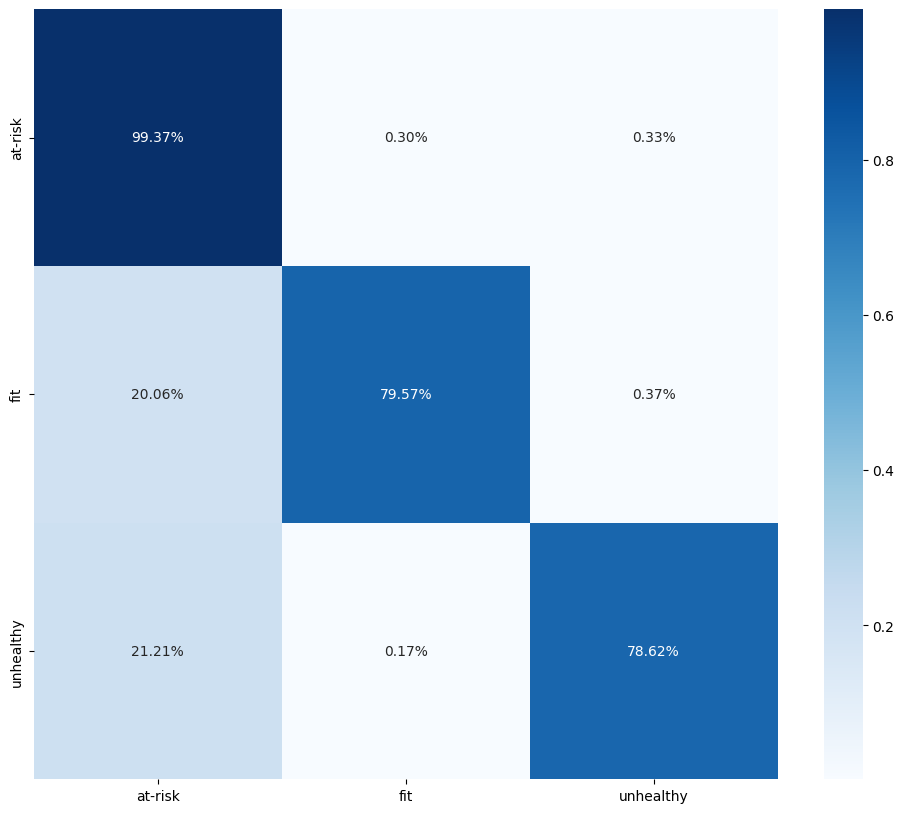

In [44]:
plt.figure(figsize=(12,10))

matrix = confusion_matrix(y_test,preds_prob,normalize='true')

sns.heatmap(
    matrix,
    fmt='.2%',
    annot=True,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues'
)

In [45]:
preds_final = clf.predict(df_testing)
preds_final

array([2., 0., 0., ..., 0., 0., 2.], shape=(295753,))

In [46]:
preds_final_fmt = le.inverse_transform(preds_final.astype(int))
preds_final_fmt

array(['unhealthy', 'at-risk', 'at-risk', ..., 'at-risk', 'at-risk',
       'unhealthy'], shape=(295753,), dtype=object)

In [ ]:
ids

0         690088
1         690089
2         690090
3         690091
4         690092
           ...  
295748    985836
295749    985837
295750    985838
295751    985839
295752    985840
Name: id, Length: 295753, dtype: int64

In [ ]:
df_result = pd.DataFrame({"id": ids, "health_condition":preds_final_fmt})
df_result.to_csv("submission.csv", index=False)